In [ ]:
from autocvd import autocvd
autocvd(num_gpus = 1)

import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import galax.coordinates as gc
import galax.dynamics as gd
import galax.potential as gp
from unxt import Quantity

import numpy as np
import matplotlib.pyplot as plt 
import jax.random as jr
import jax

m_Triaxial_halo: [1.80221395e+12]
r_Triaxial_halo: [14.0501196]
q1_Triaxial_halo: [1.]
q2_Triaxial_halo: [1.19634349]
rho_TwoPowerTriaxial_halo: [1.18366627e+08]
a_TwoPowerTriaxial_halo: [92.99985031]
b_TwoPowerTriaxial_halo: [1.]
c_TwoPowerTriaxial_halo: [2.23820918]
alpha_TwoPowerTriaxial_halo: [0.655976]
beta_TwoPowerTriaxial_halo: [2.89145527]
rho_thin_disk: [1.45955766e+09]
hr_thin_disk: [3.14537487]
hz_thin_disk: [0.25505289]
rho_thick_disk: [27144537.30221272]
hr_thick_disk: [2.18761851]
hz_thick_disk: [0.67668757]
m_bulge: [4.50136538e+09]
alpha_bulge: [1.8]
r_bulge: [1.9]
m_progenitor: [4300.]
a_progenitor: [8.43]
t_end: [4.]
ra: [229.022]
dec: [-0.112]
vr: [-58.58195009]
r: [20.72502373]
mu_ra_cosdec: [-2.84762802]
mu_dec: [-2.63075519]
j: [0]
x: [6.34774161]
y: [0.21441355]
z: [14.85683666]
vx: [-51.87950736]
vy: [-134.05177309]
vz: [-5.38853122]


Text(0, 0.5, 'y [kpc]')

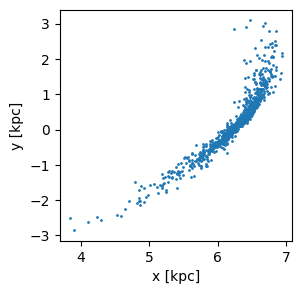

In [33]:
i = 1
data = np.load(f'../project_stream/data/streams/data_galax/simulation_{i}.npz')
sim_data = data['sim_data_carthesian']

for k in data.keys():
    if (k != 'sim_data_carthesian') & (k != 'sim_data_projected'):
        print(f"{k}: {data[k]}")

fig = plt.figure(figsize=(3, 3))
plt.scatter(sim_data[:, 0], sim_data[:, 1], s=1)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')


/export/home/vgiusepp/Odisseo/notebooks/dev/albastross/action_angle/galax/src/galax/dynamics/_src/legacy/mockstream/df/chen24.py:53: RuntimeWarning: Currently only the "no progenitor" version of the Chen+24 model is supported!
  warnings.warn(
/tmp/ipykernel_1840883/3885693259.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left')


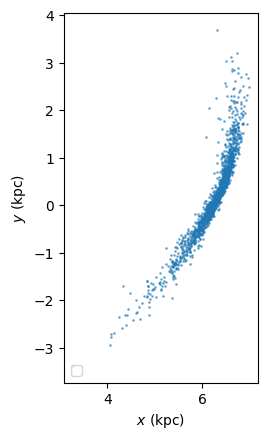

In [34]:
import jax
pot = gp.CompositePotential(

  halo = gp.TriaxialNFWPotential(m     = data['m_Triaxial_halo'][0],
                                r_s   = data['r_Triaxial_halo'][0],
                                q1     = data['q1_Triaxial_halo'][0],
                                q2     = data['q2_Triaxial_halo'][0],
                                # q2 = 6,
                                units ="galactic"),

  thin_disk = gp.MN3ExponentialPotential(m_tot = 4 * np.pi * data['rho_thin_disk'][0]*data['hr_thin_disk'][0]**2 * data['hz_thin_disk'][0],
                                                  h_R=data['hr_thin_disk'][0],
                                                  h_z=data['hz_thin_disk'][0],
                                                  units="galactic",
                                                  positive_density=True),
  thick_disk = gp.MN3ExponentialPotential(m_tot = 4 * np.pi * data['rho_thick_disk'][0] *data['hr_thick_disk'][0]**2 * data['hz_thick_disk'][0],
                                                  h_R=data['hr_thick_disk'][0],
                                                  h_z=data['hz_thick_disk'][0],
                                                  units="galactic",
                                                  positive_density=True),
  bulge = gp.PowerLawCutoffPotential(m_tot=data['m_bulge'][0],
                                            r_c=data['r_bulge'][0],
                                            alpha=data['alpha_bulge'][0],
                                            units="galactic")
)

w0 = coord.Galactocentric(x=data['x'][0]*u.kpc, y=data['y'][0]*u.kpc, z=data['z'][0]*u.kpc,
                          v_x=data['vx'][0]*u.km/u.s, v_y=data['vy'][0]*u.km/u.s, v_z=data['vz'][0]*u.km/u.s)
w0 = gc.PhaseSpacePosition(q = Quantity([w0.x.value, w0.y.value, w0.z.value], "kpc"),
                           p = Quantity([w0.v_x.value, w0.v_y.value, w0.v_z.value], "km/s"),
                           )

t_end = data['t_end'][0] * u.Gyr.to(u.Myr)
t_array = Quantity(-np.linspace(0, t_end, 1000), "Myr")


prog_mass = Quantity(data['m_progenitor'][0], "Msun")

# Chen+25 (no prog.)
# df = gd.FardalStreamDF()
df = gd.ChenStreamDF()
gen = gd.MockStreamGenerator(df, pot)
func = jax.jit(lambda k, t, w0, prog_mass: gen.run(k, t, w0, prog_mass))
stream_c25, _ = func(jr.key(0), t_array, w0, prog_mass)
# b_prog = data['a_progenitor'][0] * u.pc
# NGC3201_pot = gp.PlummerPotential(m=prog_mass, b=b_prog, units="galactic")

plt.scatter(stream_c25.q.x.value, stream_c25.q.y.value, s=1, alpha=0.5, )
plt.xlabel(r'$x\ ({\rm kpc})$')
plt.ylabel(r'$y\ ({\rm kpc})$')
plt.legend(loc='lower left')
plt.gca().set_aspect(1)
plt.show()

In [25]:
stream_c25, _ = func(jr.key(0), t_array, w0, prog_mass)


In [31]:
np.array([stream_c25.q.x.value, stream_c25.q.y.value, stream_c25.q.z.value, stream_c25.p.x.value, stream_c25.p.y.value, stream_c25.p.z.value]).T

array([[ 4.84211493e+00, -2.83145475e+00,  1.40148592e+01,
        -9.63341519e-02, -1.26783460e-01, -1.21449783e-01],
       [ 6.15507603e+00,  1.29313445e+00,  1.44311180e+01,
         1.41262608e-02, -1.42336681e-01,  1.07289582e-01],
       [ 5.48988152e+00, -9.36780870e-01,  1.39386473e+01,
        -9.64866281e-02, -1.44243017e-01, -1.07149273e-01],
       ...,
       [ 6.49300814e+00,  2.33790413e-01,  1.50013666e+01,
        -5.20360991e-02, -1.40667975e-01, -5.93759771e-03],
       [ 6.44311953e+00,  1.57491818e-01,  1.49529848e+01,
        -5.23520559e-02, -1.40229315e-01, -7.45303230e-03],
       [ 6.49924564e+00,  2.67369598e-01,  1.49948225e+01,
        -5.18073291e-02, -1.40282214e-01, -6.13302551e-03]],
      shape=(2000, 6), dtype=float32)

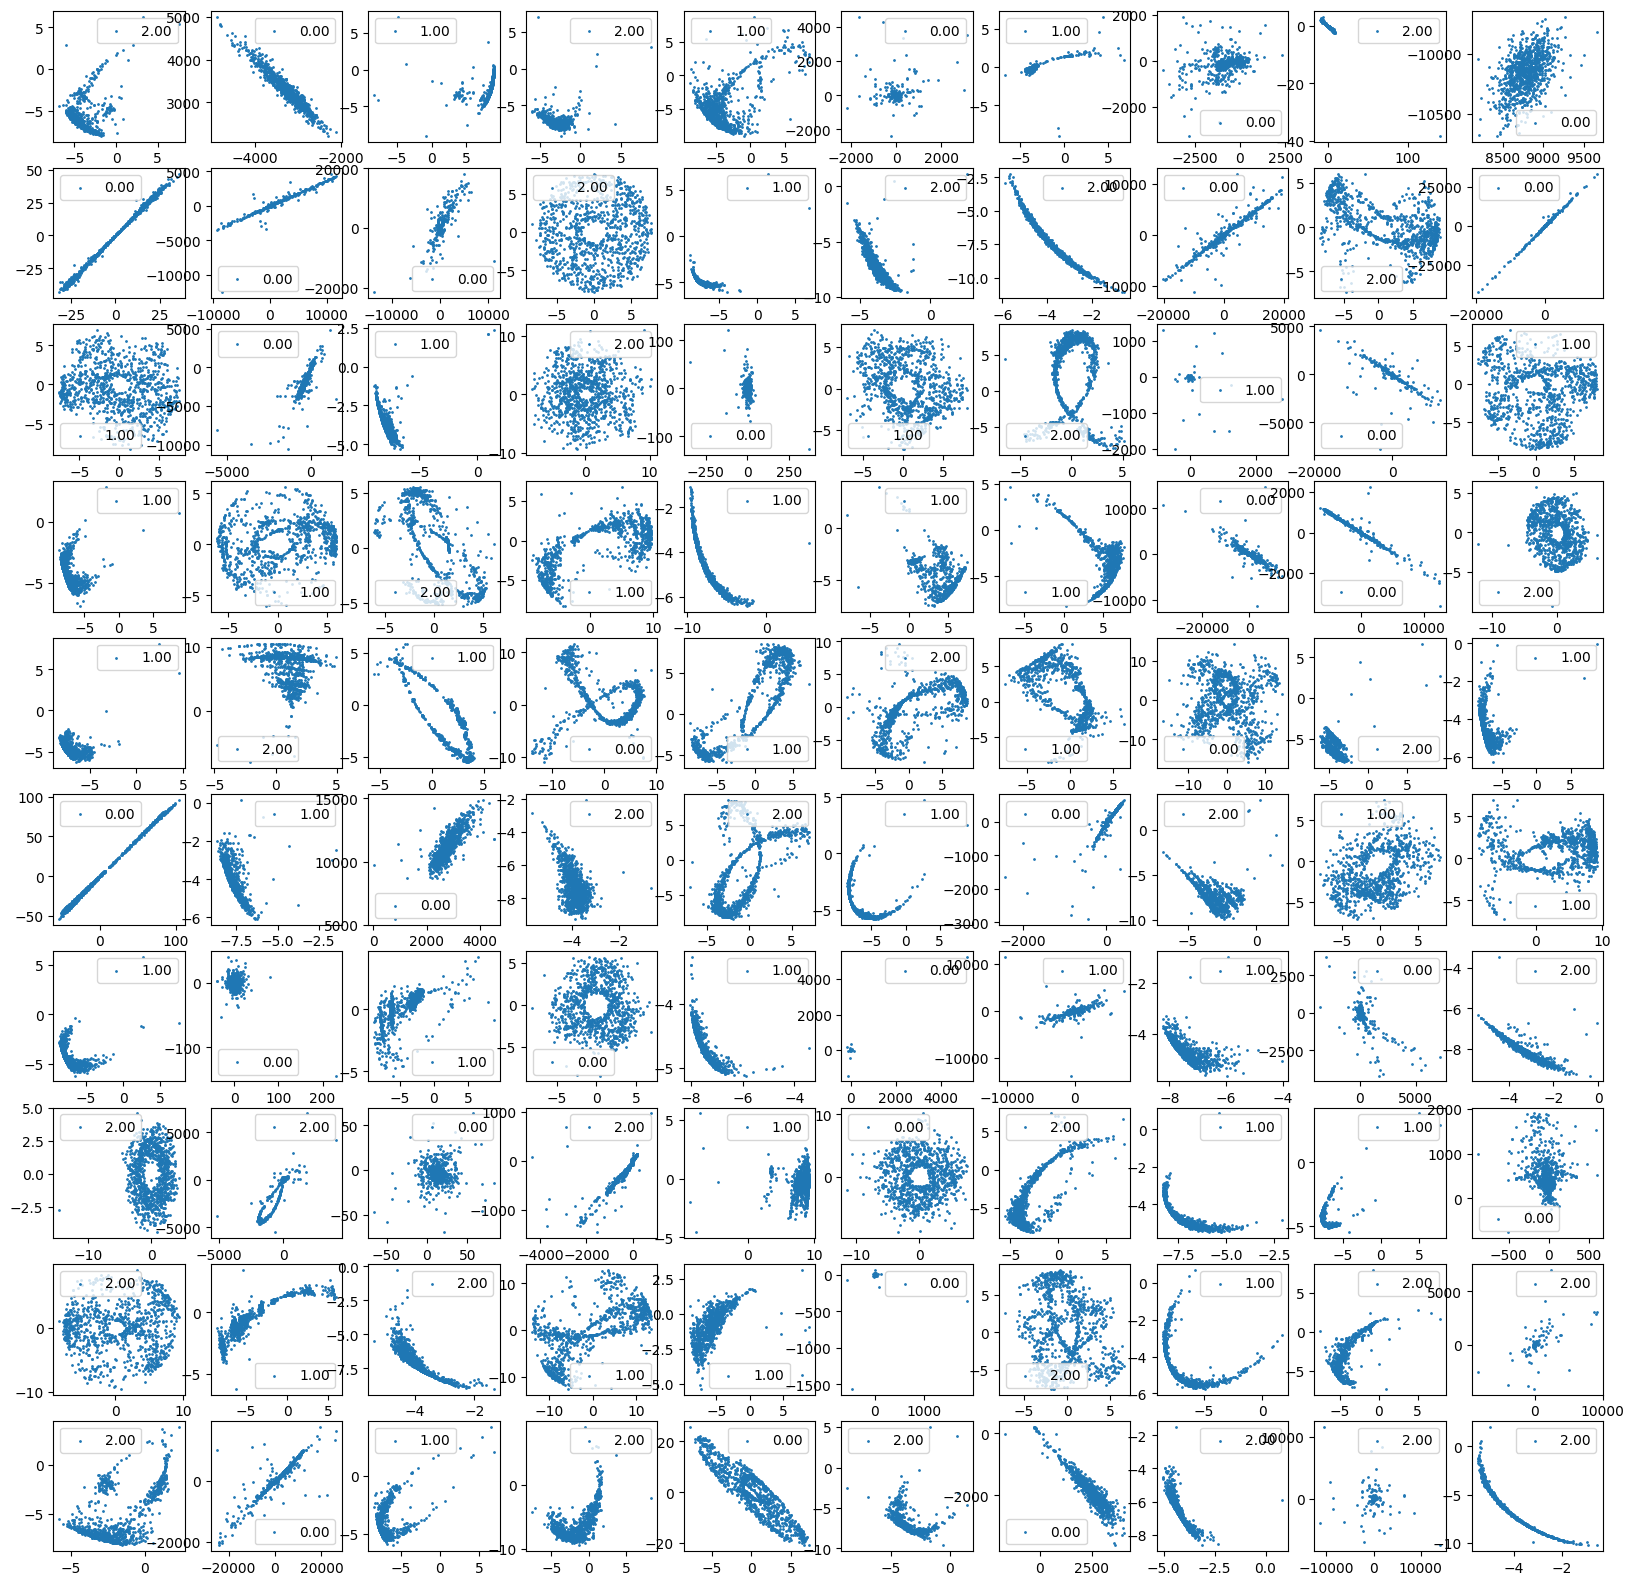

In [37]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(0, 100)):
    data = np.load(f'../project_stream/data/streams/data/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['j'][0]:.2f}")
    ax.legend()

# Multistream